## Importing Required Libraries

In this cell, we import all the essential libraries used throughout the Titanic machine learning project. These libraries cover data manipulation, visualization, preprocessing, model training, and evaluation.

### Data Handling
- **NumPy** and **Pandas** are used for numerical operations and structured data manipulation.
- **Math** provides basic mathematical utilities.

### Visualization
- **Matplotlib** and **Seaborn** help create plots for exploratory data analysis and model evaluation.

### Machine Learning Models
- **RandomForestRegressor** is used to predict missing Age values.
- **LogisticRegression**, **RandomForestClassifier**, and **XGBClassifier** are used for the final classification task (predicting survival).

### Preprocessing Tools
- **ColumnTransformer** and **Pipeline** allow us to build clean preprocessing workflows.
- **OneHotEncoder** converts categorical variables into numerical format.

### Model Evaluation
We import several metrics to evaluate model performance:
- Accuracy, Precision, Recall, F1-score  
- ROC AUC  
- Confusion Matrix  
- ROC and Precision–Recall curves  

### Utilities
- **train_test_split** for creating validation sets  
- **cross_val_score** for cross‑validation  
- **warnings** to suppress unnecessary warnings  
- **typing** for type annotations  

These imports set up the foundation for all data processing, modeling, and evaluation steps that follow in the notebook.


In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
import math
from sklearn.ensemble import RandomForestRegressor
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    roc_curve,
    precision_recall_curve,
)
from sklearn.model_selection import train_test_split , cross_val_score
from typing import Dict, List
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)

## Loading the Titanic Dataset 
In this cell, we load the training and test datasets provided by Kaggle’s Titanic competition.

In [2]:
train_df = pd.read_csv("/kaggle/input/titanic/train.csv")
test_df = pd.read_csv("/kaggle/input/titanic/test.csv")

In [3]:
train_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Inspecting the Training Dataset Structure

In this cell, we use the `info()` method to examine the structure of the training dataset.

### What this cell does
- Displays the number of rows and columns in `train_df`
- Shows the data type of each column
- Reports how many non‑null (non‑missing) values each column contains
- Indicates the memory usage of the DataFrame

### Why this step is important
Understanding the dataset structure is a crucial first step before any preprocessing or feature engineering. It helps us identify:
- Which columns contain missing values  
- Whether each feature is numerical or categorical  
- Potential issues such as incorrect data types  
- The overall completeness and quality of the dataset  

### Outcome
After running this cell, we have a clear overview of the dataset’s schema, which guides the next steps in cleaning and preparing the data.


In [4]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


## Checking Missing Values in the Training Dataset

In this cell, we calculate the number of missing values in each column of the training dataset using the `isnull().sum()` method.

### What this cell does
- Identifies which columns contain missing values.
- Counts how many missing entries each column has.
- Provides a quick overview of data completeness before preprocessing.

### Why this step is important
Detecting missing values early helps us:
- Decide which columns require imputation.
- Understand potential data quality issues.
- Plan feature engineering steps such as filling missing Age, Fare, or Embarked values.

### Outcome
The output shows a list of all columns along with the number of missing values in each. This information guides the next steps in cleaning and preparing the dataset.


In [5]:
train_df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

## Detecting Outliers in Numerical Features

In this cell, we identify potential outliers in the numerical columns of the training dataset using the Interquartile Range (IQR) method.

### What this cell does
1. **Selects numerical columns**  
   The dataset is filtered to include only columns with integer or float data types.

2. **Computes IQR statistics**  
   - `Q1`: 25th percentile  
   - `Q3`: 75th percentile  
   - `IQR = Q3 - Q1`  

3. **Applies the IQR rule**  
   A value is considered an outlier if it lies outside the range:  
   

\[
   [Q1 - 1.5 \times IQR,\; Q3 + 1.5 \times IQR]
   \]



4. **Counts outliers per column**  
   The number of outlier values in each numerical feature is calculated and sorted in descending order.

### Why this step is important
Outlier detection helps us:
- Understand the distribution of numerical features  
- Identify extreme values that may affect model performance  
- Decide whether transformations (e.g., log scaling) are needed  

### Outcome
The output shows how many outliers exist in each numerical column.  
This information guides later preprocessing decisions, such as applying log transforms to skewed features like `Fare`.


In [6]:
numeric_df = train_df.select_dtypes(include=["int64", "float64"])

Q1 = numeric_df.quantile(0.25)
Q3 = numeric_df.quantile(0.75)
IQR = Q3 - Q1

outliers = (numeric_df < (Q1 - 1.5 * IQR)) | (numeric_df > (Q3 + 1.5 * IQR))
outliers.sum().sort_values(ascending=False) 

Parch          213
Fare           116
SibSp           46
Age             11
Pclass           0
PassengerId      0
Survived         0
dtype: int64

## Visualizing Outliers with Boxplots

In this cell, we create boxplots for all numerical features in the dataset to visually inspect the presence of outliers.

### What this cell does
- Initializes a Matplotlib figure with a wide layout for better readability.
- Uses Seaborn’s `boxplot` function to draw boxplots for every numerical column in `numeric_df`.
- Rotates the x‑axis labels to prevent overlap.
- Adds a title to the plot for clarity.

### Why this step is important
Boxplots provide a clear visual summary of:
- The distribution of each numerical feature  
- The median and interquartile range (IQR)  
- Potential outliers, shown as points outside the whiskers  

This visualization complements the earlier IQR‑based outlier detection and helps confirm which features contain extreme values.

### Outcome
A set of boxplots is displayed, allowing us to quickly identify skewed distributions and outliers in numerical columns such as `Fare` or `Age`.


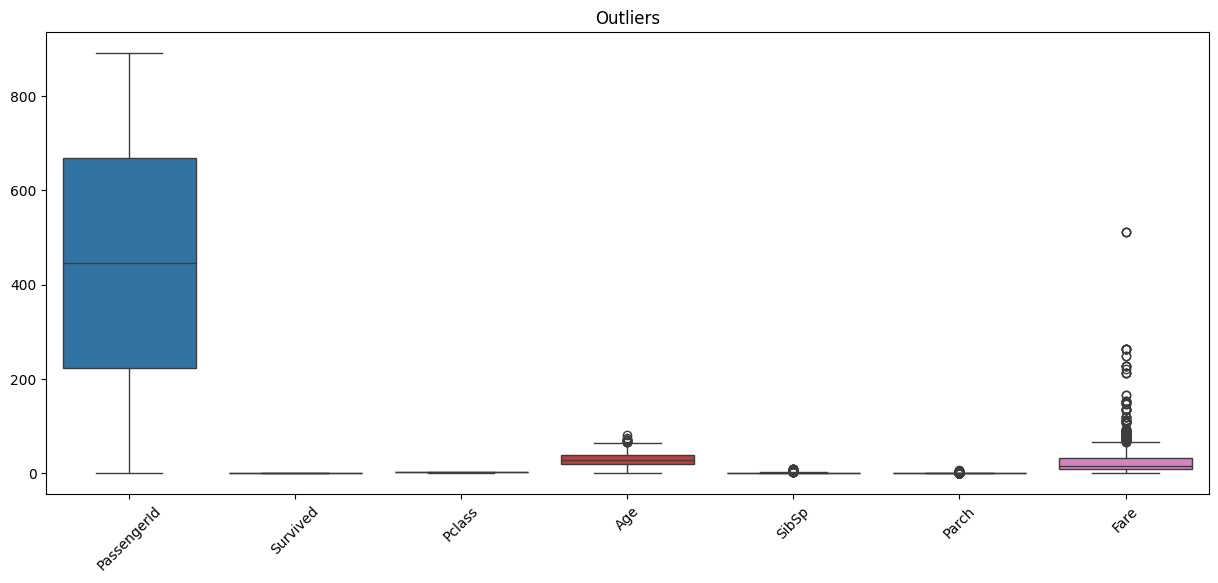

In [7]:
plt.figure(figsize=(15, 6))
sns.boxplot(data=numeric_df)
plt.xticks(rotation=45)
plt.title("Outliers")
plt.show()

## Inspecting the Training Dataset Structure

In [8]:
test_df.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [9]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    object 
 3   Sex          418 non-null    object 
 4   Age          332 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    object 
 8   Fare         417 non-null    float64
 9   Cabin        91 non-null     object 
 10  Embarked     418 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 36.1+ KB


## Visualizing Distributions of Numerical Features

In this cell, we create histograms for all numerical columns in the training dataset to better understand their distributions.

### What this cell does
1. Retrieves the list of numerical columns from `numeric_df`.
2. Calculates how many rows and columns are needed to display all histograms in a grid layout.
3. Creates a Matplotlib figure with multiple subplots.
4. Iterates through each numerical feature and plots:
   - A histogram with 20 bins
   - A kernel density estimate (KDE) curve for smoother visualization
   - A unique color for each plot using a Seaborn color palette
5. Removes any unused subplot axes to keep the figure clean.
6. Adds a main title and adjusts spacing for readability.

### Why this step is important
Visualizing feature distributions helps us:
- Identify skewed variables (e.g., `Fare`)
- Understand the spread and central tendency of each feature
- Detect unusual patterns or irregularities
- Decide whether transformations or scaling might be needed

### Outcome
A grid of histograms is displayed, providing a clear overview of how each numerical feature is distributed in the training dataset.


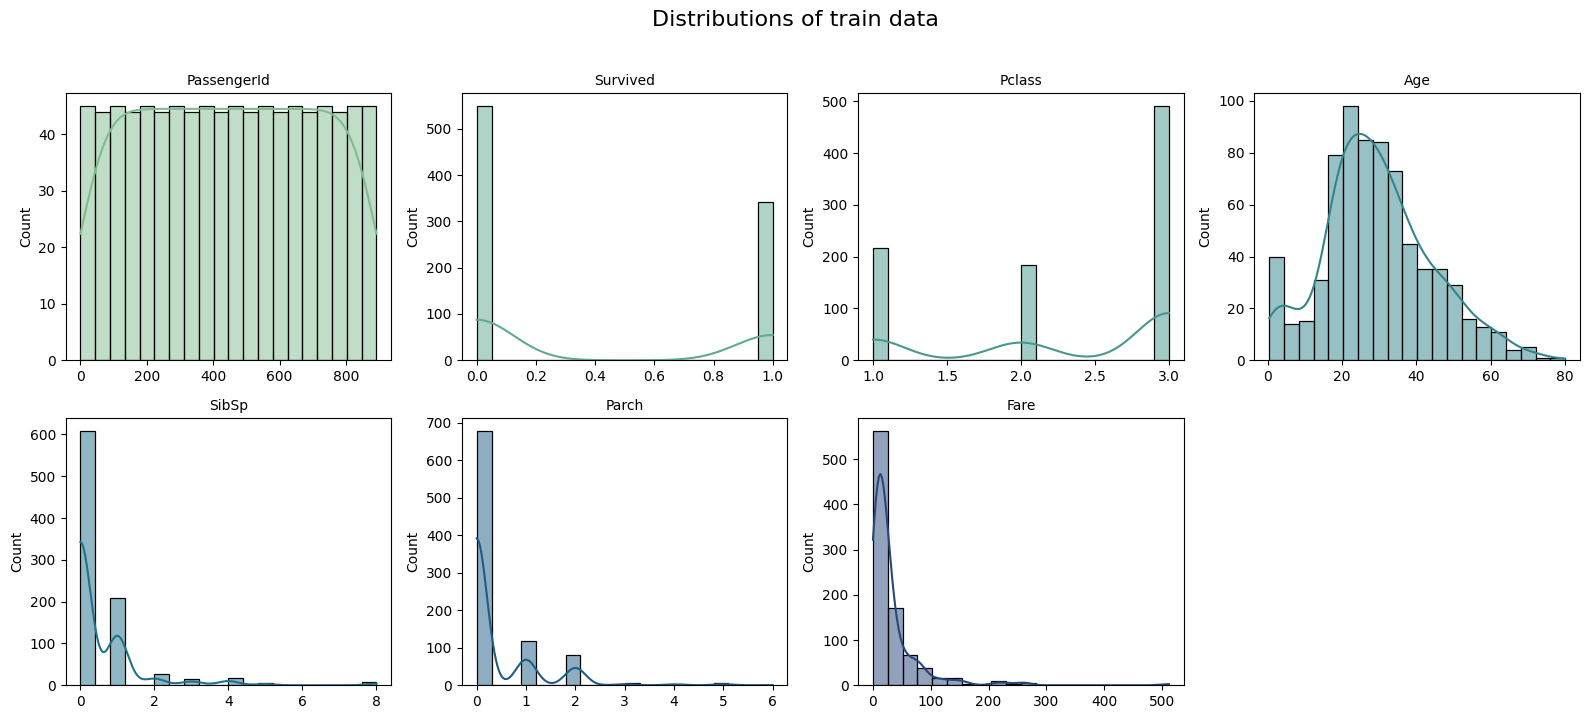

In [ ]:
numeric_cols = numeric_df.columns
n = len(numeric_cols)
cols_per_row = 4
rows = math.ceil(n / cols_per_row)
fig, axes = plt.subplots(rows, cols_per_row, figsize=(cols_per_row * 4, rows * 3.5))
axes = axes.flatten()
palette = sns.color_palette("crest", n)
for i, col in enumerate(numeric_cols):
    sns.histplot(train_df[col], bins=20, kde=True, ax=axes[i], color=palette[i])
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel("")
for ax in axes[n:]:
    ax.remove()
fig.suptitle("Distributions of train data", fontsize=16, y=1.02)
fig.tight_layout()
plt.show()

def distribution_plot(numeric_df, data):
    numeric_cols = numeric_df.columns
    n = len(numeric_cols)
    cols_per_row = 4
    rows = math.ceil(n / cols_per_row)
    fig, axes = plt.subplots(rows, cols_per_row, figsize=(cols_per_row * 4, rows * 3.5))
    axes = axes.flatten()
    palette = sns.color_palette("crest", n)
    for i, col in enumerate(numeric_cols):
        sns.histplot(train_df[col], bins=20, kde=True, ax=axes[i], color=palette[i])
        axes[i].set_title(col, fontsize=10)
        axes[i].set_xlabel("")
    for ax in axes[n:]:
        ax.remove()
    fig.suptitle(f"Distributions of {data} data", fontsize=16, y=1.02)
    fig.tight_layout()
    plt.show()

## Correlation of Numerical Features with the Target Variable

In this cell, we compute and display the correlation between each numerical feature and the target variable `Survived`.

### What this cell does
1. **Computes correlations**  
   - Selects only the numerical columns from the training dataset.  
   - Calculates the correlation matrix.  
   - Extracts the correlation values specifically between each numerical feature and `Survived`.  
   - Sorts the correlations in descending order.

2. **Displays the results in a table**  
   - Creates a Matplotlib figure sized dynamically based on the number of features.  
   - Removes axes for a cleaner look.  
   - Renders a table showing each feature and its correlation with `Survived`.  
   - Adjusts font size and scaling for readability.

### Why this step is important
Correlation analysis helps us:
- Identify which numerical features have the strongest relationship with survival.
- Understand which variables may be more predictive in the model.
- Detect weak or irrelevant features that may not contribute much to performance.

### Outcome
A neatly formatted table is displayed, listing numerical features alongside their correlation with the target variable. This provides a quick overview of feature importance from a linear perspective.


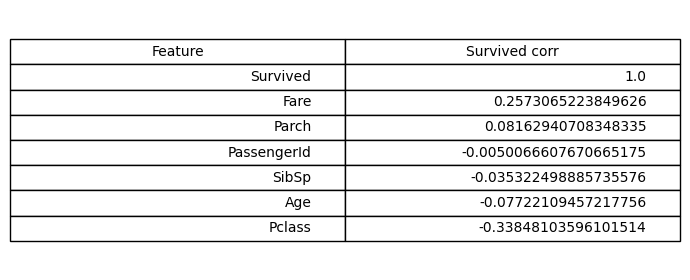

In [ ]:
corr_table = train_df[numeric_df.columns].corr()['Survived'].sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(7, 0.2 * len(corr_table) + 1.5))
ax.axis('off')
ax.axis('tight')
table = ax.table(
    cellText=corr_table.reset_index().values,
    colLabels=['Feature', 'Survived corr'],
    loc='center',
)
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.3)
fig.tight_layout()
plt.show()

## Correlation Matrix Heatmap for Numerical Features

In this cell, we compute and visualize the correlation matrix for all numerical features in the training dataset.

### What this cell does
1. **Computes the correlation matrix**  
   - Uses the numerical columns extracted earlier (`numeric_df.columns`).  
   - Calculates pairwise Pearson correlations between all numerical features.

2. **Creates a heatmap visualization**  
   - Displays correlation values using a diverging color palette (`RdBu_r`).  
   - Annotates each cell with the correlation value (rounded to two decimals).  
   - Centers the colormap at zero to clearly distinguish positive and negative correlations.  
   - Adjusts layout, label rotation, and figure size for readability.

### Why this step is important
A correlation heatmap helps us:
- Identify relationships between numerical features  
- Detect multicollinearity (high correlation between predictors)  
- Understand which features may provide redundant information  
- Gain insights into how features relate to each other before modeling  

### Outcome
A heatmap is displayed showing the correlation structure of all numerical variables.  
This visualization provides a comprehensive overview of feature interactions and helps guide feature selection and preprocessing decisions.


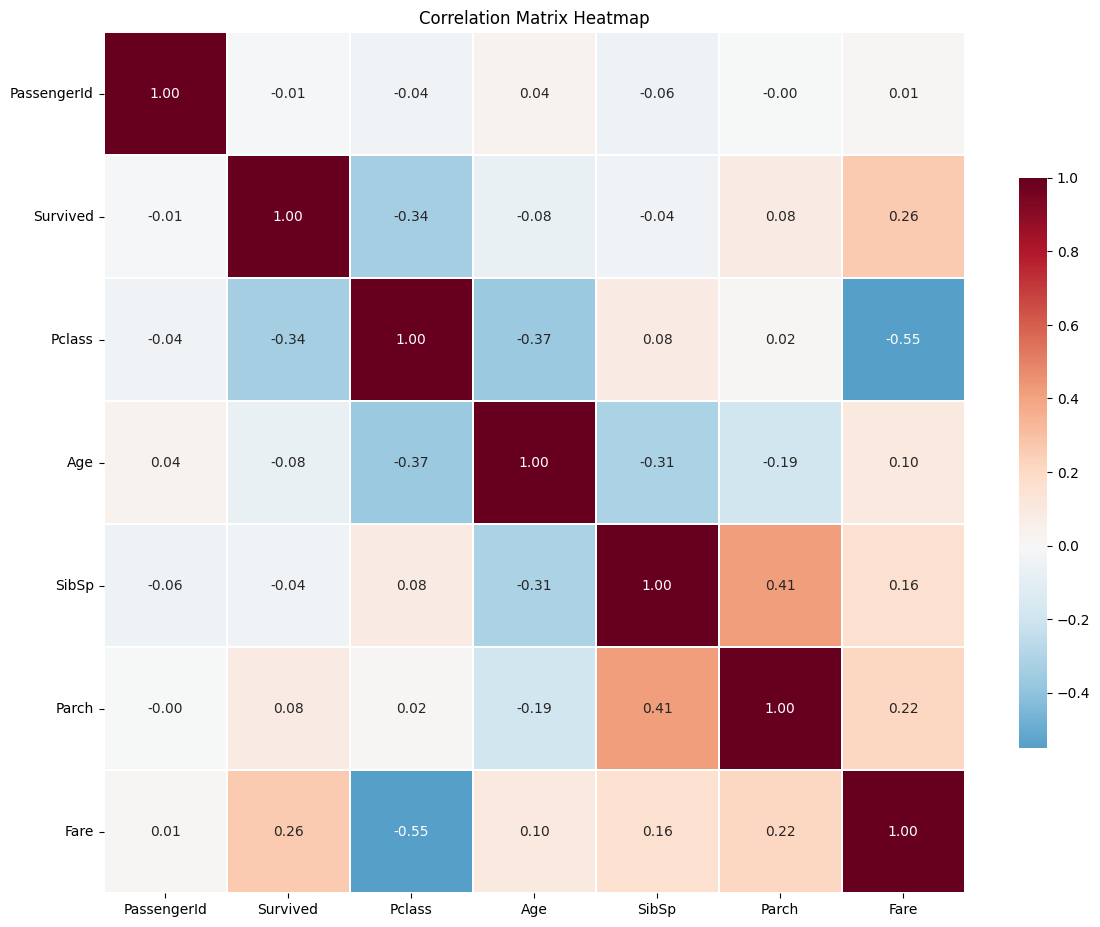

In [12]:
corr_matrix = train_df[numeric_df.columns].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    linewidths=0.3,
    square=True,
    cbar_kws={"shrink": 0.6},
)
plt.xticks(rotation=0, ha="center")
plt.yticks(rotation=0)
plt.title("Correlation Matrix Heatmap")
plt.tight_layout()
plt.show()

## Combining Train and Test Sets for Unified Preprocessing

In this cell, we prepare the training and test datasets for consistent preprocessing by merging them into a single DataFrame.

### What this cell does
1. Adds a new column `is_train` to both datasets:
   - `1` for rows originating from the training set  
   - `0` for rows originating from the test set  

2. Concatenates `train_df` and `test_df` into a single DataFrame called `full_df` using `pd.concat()`.

### Why this step is important
Many preprocessing steps (such as encoding categorical variables, extracting titles, or engineering new features) must be applied **identically** to both the training and test datasets.  
Merging them ensures:
- Consistent feature engineering  
- Matching column structure  
- Avoiding mismatched encodings between train and test  

### Outcome
A unified DataFrame `full_df` is created, containing all rows from both datasets along with a flag (`is_train`) that allows us to separate them again after preprocessing.


In [13]:
train_df['is_train'] = 1 
test_df['is_train'] = 0 
full_df = pd.concat([train_df, test_df], ignore_index=True) 

## Filling Missing Values in the 'Embarked' Column

In this cell, we handle missing values in the `Embarked` feature of the combined dataset.

### What this cell does
- Identifies missing values in the `Embarked` column of `full_df`.
- Replaces all missing entries with the most frequent value (mode) from the training dataset.
- Uses `train_df['Embarked'].mode()[0]` to ensure the imputation is based only on the training data, avoiding data leakage.

### Why this step is important
The `Embarked` feature contains a small number of missing values. Since it is a categorical variable, filling missing entries with the most common category is a simple and effective strategy.  
This ensures:
- No missing values remain in the column  
- The model receives consistent and complete input data  

### Outcome
All missing values in the `Embarked` column of `full_df` are replaced with the most frequent embarkation port from the training dataset.


In [14]:
full_df['Embarked'] = full_df['Embarked'].fillna(train_df['Embarked'].mode()[0])

## Filling Missing Values in the 'Fare' Column

In this cell, we handle missing values in the `Fare` feature of the combined dataset.

### What this cell does
- Identifies missing entries in the `Fare` column of `full_df`.
- Replaces all missing values with the median fare from the entire combined dataset.
- Uses `full_df['Fare'].median()` to ensure the imputation reflects the overall distribution of the feature.

### Why this step is important
The `Fare` column contains a small number of missing values, and since it is a numerical feature with a skewed distribution, the **median** is a more robust and reliable choice than the mean.  
This prevents extreme values from influencing the imputation.

### Outcome
All missing values in the `Fare` column are replaced with the median fare, ensuring the feature is complete and ready for further preprocessing or modeling.


In [15]:
full_df['Fare'] = full_df['Fare'].fillna(full_df['Fare'].median())

## Extracting Cabin-Related Features

In this cell, we engineer new features from the `Cabin` column to capture useful information while removing the original sparse column.

### What this cell does
1. **Extracts the deck letter**
   - The first character of the `Cabin` value represents the passenger's deck (A–G).
   - `full_df['Cabin'].str[0]` extracts this letter.
   - Missing values are replaced with `'Unknown'` because many passengers do not have cabin information.

2. **Creates a binary feature `HasCabin`**
   - Indicates whether the passenger has a recorded cabin number.
   - `1` if `Cabin` is not null  
   - `0` if `Cabin` is missing  
   - This helps the model capture the difference between passengers with assigned cabins (often higher class) and those without.

3. **Drops the original `Cabin` column**
   - The original column is highly sparse and contains many unique values.
   - After extracting useful information, it is removed to simplify the dataset.

### Why this step is important
The `Cabin` column contains valuable but incomplete information.  
By extracting the deck and creating a binary indicator, we preserve meaningful patterns while avoiding issues caused by missing or overly granular data.

### Outcome
Two new features are added:
- `Deck`  
- `HasCabin`  

The original `Cabin` column is removed, and the dataset becomes cleaner and more informative for modeling.


In [16]:
full_df['Deck'] = full_df['Cabin'].str[0]
full_df['Deck'] = full_df['Deck'].fillna('Unknown')
full_df['HasCabin'] = full_df['Cabin'].notnull().astype(int)
full_df = full_df.drop(columns=['Cabin'])

## Extracting and Standardizing Passenger Titles

In this cell, we extract the passenger title from the `Name` column and standardize it to create a more meaningful categorical feature.

### What this cell does
1. **Extracts titles from the Name column**  
   - Uses a regular expression to capture the title (e.g., Mr, Mrs, Miss, Master).  
   - Stores the extracted title in a new column called `Title`.

2. **Standardizes similar titles**  
   - Replaces variations such as `Mlle` and `Ms` with `Miss`.  
   - Replaces `Mme` with `Mrs`.  
   - This reduces unnecessary categories and improves model performance.

3. **Groups rare titles into a single category**  
   - Titles such as `Lady`, `Countess`, `Capt`, `Col`, `Don`, `Dr`, and others are grouped under the label `Rare`.  
   - These titles appear very infrequently and would otherwise create sparse categories.

### Why this step is important
Passenger titles contain valuable information about:
- Social status  
- Gender  
- Age group  
- Cultural background  

These patterns often correlate strongly with survival rates on the Titanic.  
Standardizing and grouping titles ensures the feature is clean, consistent, and useful for modeling.

### Outcome
A new, well‑structured categorical feature `Title` is added to the dataset, ready for use in further preprocessing and model training.


In [17]:
full_df['Title'] = full_df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False) 
rare_titles = ['Lady', 'Countess', 'Capt', 'Col', 'Don', 'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona'] 
full_df['Title'] = full_df['Title'].replace({ 'Mlle': 'Miss', 'Ms': 'Miss', 'Mme': 'Mrs' }) 
full_df['Title'] = full_df['Title'].replace(rare_titles, 'Rare')

<>:1: SyntaxWarning: invalid escape sequence '\.'
<>:1: SyntaxWarning: invalid escape sequence '\.'
/tmp/ipykernel_17/2275931960.py:1: SyntaxWarning: invalid escape sequence '\.'
  full_df['Title'] = full_df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)


## Creating the 'FamilySize' Feature

In this cell, we create a new feature called `FamilySize` to represent the total number of family members traveling together.

### What this cell does
- Combines the `SibSp` (siblings/spouses aboard) and `Parch` (parents/children aboard) columns.
- Adds `1` to include the passenger themselves.
- Stores the result in a new column named `FamilySize`.

### Why this step is important
Family size is known to be an informative feature in the Titanic dataset.  
It helps capture patterns such as:
- Passengers traveling alone often had lower survival rates.
- Very large families also tended to have lower survival rates.
- Small to medium-sized families sometimes had better outcomes.

### Outcome
A new numerical feature `FamilySize` is added to the dataset, which can improve model performance by providing additional context about each passenger's group size.


In [18]:
full_df['FamilySize'] = full_df['SibSp'] + full_df['Parch'] + 1

## Building a Preprocessing Pipeline for Age Prediction

In this cell, we define the preprocessing steps and create a machine learning pipeline that will later be used to predict missing `Age` values.

### Defining Feature Groups
Two sets of features are specified:
- **Categorical columns:** `Sex`, `Embarked`, `Title`, `Deck`  
- **Numerical columns:** `Pclass`, `SibSp`, `Parch`, `Fare`, `FamilySize`, `HasCabin`

These features will be used to train a model that estimates missing ages.

### Creating the Preprocessor
A `ColumnTransformer` is defined to handle different feature types:
- **Categorical features:** encoded using `OneHotEncoder`  
  - `handle_unknown='ignore'` ensures the model does not fail when encountering unseen categories.
- **Numerical features:** passed through without modification (`'passthrough'`)

This ensures consistent and automated preprocessing for both training and prediction.

### Building the Age Prediction Pipeline
A `Pipeline` is created with two steps:
1. **Preprocessing step**  
   Applies the transformations defined in the `ColumnTransformer`.
2. **Model step**  
   Uses a `RandomForestRegressor` with:
   - `n_estimators=200` (number of trees)
   - `random_state=42` (reproducibility)

### Why this step is important
The `Age` column contains missing values, and predicting them using a model is often more accurate than simple imputation (mean/median).  
By combining preprocessing and modeling into a single pipeline:
- The workflow becomes cleaner and less error‑prone  
- The same transformations are applied consistently during training and prediction  
- The model can learn complex relationships between features and age  

### Outcome
A ready‑to‑use pipeline (`age_model`) is created, which will later be fitted on rows with known ages and used to predict missing values in the dataset.


In [19]:
categorical_cols = ['Sex', 'Embarked', 'Title', 'Deck']
numeric_cols = ['Pclass', 'SibSp', 'Parch', 'Fare', 'FamilySize', 'HasCabin']

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
        ('num', 'passthrough', numeric_cols)
    ]
)

age_model = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('model', RandomForestRegressor(n_estimators=200, random_state=42))
])

## Predicting and Filling Missing Age Values

In this cell, we use the previously built `age_model` pipeline to predict missing values in the `Age` column.

### What this cell does

1. **Creates a working copy of the dataset**
   - `age_df = full_df.copy()` ensures we do not modify the original DataFrame unintentionally.

2. **Splits the data into two subsets**
   - `train_age`: rows where `Age` is known  
   - `test_age`: rows where `Age` is missing  

3. **Defines the feature set for age prediction**
   The model uses the following features to estimate age:
   - `Pclass`, `Sex`, `SibSp`, `Parch`, `Fare`, `Embarked`, `Title`, `FamilySize`, `Deck`, `HasCabin`

4. **Fits the age prediction model**
   - The pipeline (`age_model`) is trained on rows with known ages.

5. **Predicts missing ages**
   - The model generates age estimates for all rows where `Age` is null.

6. **Fills the missing values**
   - The predicted ages are inserted back into `full_df` in place of missing entries.

### Why this step is important
The `Age` column contains many missing values, and age is an important predictor of survival.  
Using a machine learning model to estimate missing ages:
- Produces more realistic values than simple mean/median imputation  
- Preserves relationships between age and other features  
- Improves the quality of the dataset for downstream modeling  

### Outcome
All missing values in the `Age` column are replaced with model‑predicted estimates, resulting in a complete and more informative dataset.


In [20]:
age_df = full_df.copy()

train_age = age_df[age_df['Age'].notnull()]
test_age  = age_df[age_df['Age'].isnull()]

age_features = [ 'Pclass', 'Sex', 'SibSp', 'Parch', 'Fare', 'Embarked', 'Title', 'FamilySize', 'Deck', 'HasCabin' ]

age_model.fit(train_age[age_features], train_age['Age'])
predicted_ages = age_model.predict(test_age[age_features])
full_df.loc[full_df['Age'].isnull(), 'Age'] = predicted_ages 

## Removing Unnecessary Columns

In this cell, we drop several columns from the dataset that are not useful for modeling.

### What this cell does
- Removes the following columns from `full_df`:
  - `PassengerId`
  - `Name`
  - `Ticket`

### Why these columns are removed
- **PassengerId**  
  A simple identifier with no predictive value.

- **Name**  
  Although useful for extracting titles (which we already did), the full name itself does not provide additional meaningful information for the model.

- **Ticket**  
  Contains many unique values with no clear pattern or structure.  
  Encoding it would add noise rather than useful signal.

### Outcome
The dataset becomes cleaner and more focused on features that contribute to prediction.  
All unnecessary or overly granular columns are removed, reducing dimensionality and simplifying the modeling process.


In [21]:
full_df = full_df.drop(columns=['PassengerId', 'Name', 'Ticket'])

In [22]:
full_df = pd.get_dummies(full_df, columns=['Sex', 'Embarked', 'Title', 'Deck'], drop_first=True)

## One-Hot Encoding Categorical Features

In this cell, we convert several categorical columns into numerical format using one-hot encoding.

### What this cell does
- Applies `pd.get_dummies()` to the following categorical columns:
  - `Sex`
  - `Embarked`
  - `Title`
  - `Deck`
- Creates a separate binary column for each category.
- Uses `drop_first=True` to avoid the dummy variable trap by removing the first category of each feature.

### Why this step is important
Machine learning models require numerical input.  
One-hot encoding:
- Converts categorical variables into a machine‑readable format  
- Preserves category information without imposing an artificial order  
- Prevents multicollinearity by dropping the first dummy column  

### Outcome
All selected categorical features are transformed into multiple binary columns, and the dataset becomes fully numerical and ready for model training.


In [23]:
full_df['Fare'] = full_df['Fare'].map(lambda x: np.log(x + 1)) 

## Splitting the Combined Dataset Back into Train and Test Sets

After completing all preprocessing steps on the unified dataset (`full_df`), we now separate it back into training and test sets.

### What this cell does

1. **Recreates the processed training set**
   - Selects rows where `is_train == 1`
   - Drops the helper column `is_train`
   - The resulting DataFrame (`train_processed`) contains:
     - All engineered features
     - The target column `Survived`

2. **Recreates the processed test set**
   - Selects rows where `is_train == 0`
   - Drops `is_train` and (if present) `Survived`
   - The resulting DataFrame (`test_processed`) contains:
     - All engineered features
     - No target column (as required for Kaggle submission)

### Why this step is important
We merged the datasets earlier to ensure consistent preprocessing.  
Now that all transformations are complete, we must split them again so that:
- The training set can be used to fit machine learning models  
- The test set can be used to generate predictions for submission  

### Outcome
Two fully processed datasets are created:
- `train_processed` — ready for model training  
- `test_processed` — ready for generating final predictions  


In [24]:
train_processed = full_df[full_df['is_train'] == 1].drop(columns=['is_train']) 
test_processed = full_df[full_df["is_train"] == 0].drop(columns=["is_train", "Survived"], errors="ignore")

## Inspecting the Processed Training Dataset

In this cell, we perform a quick inspection of the fully processed training dataset to verify that preprocessing steps were applied correctly.

### What this cell does

1. **`train_processed.head()`**
   - Displays the first five rows of the processed training dataset.
   - Allows us to visually confirm:
     - All categorical variables have been one‑hot encoded
     - Engineered features (e.g., `FamilySize`, `HasCabin`, `Title_*`) are present
     - No unwanted columns remain (e.g., `Name`, `Ticket`, `PassengerId`)
     - The target variable `Survived` is still included

2. **`train_processed.info()`**
   - Prints a concise summary of the dataset, including:
     - Number of rows and columns
     - Data types of each feature
     - Memory usage
     - Whether any columns still contain missing values

### Why this step is important
Before training a machine learning model, it is essential to confirm that:
- The dataset is fully numerical  
- All preprocessing steps were applied correctly  
- No missing values remain  
- The feature count matches expectations  

This quick inspection helps catch issues early and ensures the dataset is ready for modeling.

### Outcome
You get a clear view of the structure and content of `train_processed`, confirming that the dataset is clean, consistent, and ready for model training.


In [25]:
train_processed.head()

,Survived,Pclass,Age,SibSp,Parch,Fare,HasCabin,FamilySize,Sex_male,Embarked_Q,...,Title_Mrs,Title_Rare,Deck_B,Deck_C,Deck_D,Deck_E,Deck_F,Deck_G,Deck_T,Deck_Unknown
0,0.0,3,22.0,1,0,2.110213,0,2,True,False,...,False,False,False,False,False,False,False,False,False,True
1,1.0,1,38.0,1,0,4.280593,1,2,False,False,...,True,False,False,True,False,False,False,False,False,False
2,1.0,3,26.0,0,0,2.188856,0,1,False,False,...,False,False,False,False,False,False,False,False,False,True
3,1.0,1,35.0,1,0,3.990834,1,2,False,False,...,True,False,False,True,False,False,False,False,False,False
4,0.0,3,35.0,0,0,2.202765,0,1,True,False,...,False,False,False,False,False,False,False,False,False,True


In [26]:
train_processed.info()

<class 'pandas.core.frame.DataFrame'>
Index: 891 entries, 0 to 890
Data columns (total 23 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Survived      891 non-null    float64
 1   Pclass        891 non-null    int64  
 2   Age           891 non-null    float64
 3   SibSp         891 non-null    int64  
 4   Parch         891 non-null    int64  
 5   Fare          891 non-null    float64
 6   HasCabin      891 non-null    int64  
 7   FamilySize    891 non-null    int64  
 8   Sex_male      891 non-null    bool   
 9   Embarked_Q    891 non-null    bool   
 10  Embarked_S    891 non-null    bool   
 11  Title_Miss    891 non-null    bool   
 12  Title_Mr      891 non-null    bool   
 13  Title_Mrs     891 non-null    bool   
 14  Title_Rare    891 non-null    bool   
 15  Deck_B        891 non-null    bool   
 16  Deck_C        891 non-null    bool   
 17  Deck_D        891 non-null    bool   
 18  Deck_E        891 non-null    bool 

## Inspecting the Processed Test Dataset

In this cell, we perform a quick inspection of the fully processed Test dataset to verify that preprocessing steps were applied correctly.

In [27]:
test_processed.head()

,Pclass,Age,SibSp,Parch,Fare,HasCabin,FamilySize,Sex_male,Embarked_Q,Embarked_S,...,Title_Mrs,Title_Rare,Deck_B,Deck_C,Deck_D,Deck_E,Deck_F,Deck_G,Deck_T,Deck_Unknown
891,3,34.5,0,0,2.178064,0,1,True,True,False,...,False,False,False,False,False,False,False,False,False,True
892,3,47.0,1,0,2.079442,0,2,False,False,True,...,True,False,False,False,False,False,False,False,False,True
893,2,62.0,0,0,2.369075,0,1,True,True,False,...,False,False,False,False,False,False,False,False,False,True
894,3,27.0,0,0,2.268252,0,1,True,False,True,...,False,False,False,False,False,False,False,False,False,True
895,3,22.0,1,1,2.586824,0,3,False,False,True,...,True,False,False,False,False,False,False,False,False,True


In [28]:
test_processed.info()

<class 'pandas.core.frame.DataFrame'>
Index: 418 entries, 891 to 1308
Data columns (total 22 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Pclass        418 non-null    int64  
 1   Age           418 non-null    float64
 2   SibSp         418 non-null    int64  
 3   Parch         418 non-null    int64  
 4   Fare          418 non-null    float64
 5   HasCabin      418 non-null    int64  
 6   FamilySize    418 non-null    int64  
 7   Sex_male      418 non-null    bool   
 8   Embarked_Q    418 non-null    bool   
 9   Embarked_S    418 non-null    bool   
 10  Title_Miss    418 non-null    bool   
 11  Title_Mr      418 non-null    bool   
 12  Title_Mrs     418 non-null    bool   
 13  Title_Rare    418 non-null    bool   
 14  Deck_B        418 non-null    bool   
 15  Deck_C        418 non-null    bool   
 16  Deck_D        418 non-null    bool   
 17  Deck_E        418 non-null    bool   
 18  Deck_F        418 non-null    bo

## Defining a Collection of Machine Learning Models

In this cell, we define a function `get_models()` that returns a dictionary of machine learning models to be trained and evaluated on the processed Titanic dataset.

### What this cell does

The function creates and returns a dictionary containing three different classification algorithms:

1. **Logistic Regression**
   - A simple, interpretable linear model.
   - Configured with `max_iter=500` to ensure convergence.

2. **Random Forest Classifier**
   - An ensemble of decision trees.
   - Uses:
     - `n_estimators=300` trees
     - `random_state=42` for reproducibility
     - `n_jobs=-1` to use all available CPU cores

3. **XGBoost Classifier**
   - A powerful gradient boosting model.
   - Configured with:
     - `n_estimators=400`
     - `max_depth=4`
     - `learning_rate=0.05`
     - `subsample=0.9` and `colsample_bytree=0.9` for regularization
     - `random_state=42`
     - `n_jobs=-1` for parallel computation

### Why this step is important
By organizing models into a dictionary:
- You can easily loop through them for training and evaluation.
- It simplifies comparison of different algorithms.
- It keeps the workflow clean and modular.

### Outcome
The function `get_models()` returns a ready‑to‑use dictionary of three diverse classifiers, enabling efficient model benchmarking and selection.


In [29]:
def get_models() -> Dict[str, object]:
    models = {
        "LogisticRegression": LogisticRegression(max_iter=500),
        "RandomForestClassifier": RandomForestClassifier(
            n_estimators=300,
            random_state=42,
            n_jobs=-1,
        ),
        "XGBClassifier" : XGBClassifier(
            n_estimators=400,
            max_depth=4,
            learning_rate=0.05,
            subsample=0.9,
            colsample_bytree=0.9,
            random_state=42,
            n_jobs=-1,
        ),

    }
    return models

## Explanation of the `train_single_model` Function

This function handles the complete workflow for training a machine‑learning model, evaluating it on a validation set, and generating predictions for the test set. It returns a dictionary containing all evaluation metrics and prediction outputs.

In [30]:
def train_single_model(model_name, model, X_train_full, y_train_full, X_test):
    X_train, X_val, y_train, y_val = train_test_split(
        X_train_full, y_train_full, test_size=0.2, random_state=42, stratify=y_train_full
    )

    model.fit(X_train, y_train)

    y_pred = model.predict(X_val)

    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_val)[:, 1]
    else:
        raw = model.decision_function(X_val)
        y_prob = (raw - raw.min()) / (raw.max() - raw.min())

    result = {
        "model": model_name,
        "Accuracy": accuracy_score(y_val, y_pred),
        "Precision": precision_score(y_val, y_pred),
        "Recall": recall_score(y_val, y_pred),
        "F1": f1_score(y_val, y_pred),
        "AUC": roc_auc_score(y_val, y_prob),
        "y_val": y_val,
        "y_pred": y_pred,
        "y_prob": y_prob,
    }

    test_pred = model.predict(X_test)
    result["test_pred"] = test_pred

    return result

## Plotting the Confusion Matrix for Model Evaluation

This function visualizes the confusion matrix for a trained model, helping assess how well it distinguishes between the two classes (survived vs. not survived).

### What the function does

1. **Extracts validation labels and predictions**
   - `y_val`: the true labels from the validation set  
   - `y_pred`: the model’s predicted labels  

2. **Computes the confusion matrix**
   - Uses `confusion_matrix(y_val, y_pred)` to generate a 2×2 matrix showing:
     - True Positives (TP)
     - True Negatives (TN)
     - False Positives (FP)
     - False Negatives (FN)

3. **Visualizes the matrix using a heatmap**
   - Displays the matrix with:
     - Annotated cell values  
     - A blue color palette  
     - Clear axis labels (“Predicted” vs. “Actual”)  
     - A title indicating which model the plot belongs to  

4. **Shows the plot**
   - The figure is rendered with a compact size for readability.

### Why this step is important
A confusion matrix provides deeper insight into model performance than accuracy alone.  
It helps identify:
- Whether the model is missing positive cases (high FN)
- Whether it incorrectly predicts positives (high FP)
- Whether it is biased toward one class

This is especially valuable for datasets like Titanic, where class imbalance exists.

### Outcome
A clean, easy‑to‑interpret heatmap is displayed, showing how the model performs across all prediction categories.


In [31]:
def plot_confusion(result):
    y_val = result["y_val"]
    y_pred = result["y_pred"]

    cm = confusion_matrix(y_val, y_pred)

    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"Confusion Matrix - {result['model']}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

## Plotting the ROC Curve for Model Evaluation

This function visualizes the ROC (Receiver Operating Characteristic) curve for a trained model, providing insight into its ability to distinguish between the two classes.

### What the function does

1. **Extracts validation labels and predicted probabilities**
   - `y_val`: true labels from the validation set  
   - `y_prob`: predicted probabilities for the positive class  

2. **Computes ROC curve values**
   - Uses `roc_curve(y_val, y_prob)` to calculate:
     - **FPR** (False Positive Rate)
     - **TPR** (True Positive Rate)
     - Thresholds (not used in the plot)

3. **Plots the ROC curve**
   - The main curve shows the trade‑off between TPR and FPR.
   - A diagonal red dashed line (`r--`) represents a random classifier baseline.
   - The model’s AUC score is displayed in the legend.

4. **Adds labels and formatting**
   - X‑axis: False Positive Rate  
   - Y‑axis: True Positive Rate  
   - Title includes the model name  
   - A legend shows the AUC value  

5. **Displays the plot**
   - The figure is rendered with a clean, readable layout.

### Why this step is important
The ROC curve provides a threshold‑independent evaluation of model performance.  
It helps assess:
- How well the model separates positive and negative classes  
- Whether the model is significantly better than random guessing  
- The overall quality of probability predictions  

A higher AUC indicates stronger discriminative ability.

### Outcome
A clear ROC curve is displayed, allowing you to visually compare classifier performance and understand how well the model distinguishes between survivors and non‑survivors.


In [32]:
def plot_roc_curve(result):
    y_val = result["y_val"]
    y_prob = result["y_prob"]

    fpr, tpr, _ = roc_curve(y_val, y_prob)

    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=f"AUC = {result['AUC']:.3f}")
    plt.plot([0, 1], [0, 1], "r--")
    plt.title(f"ROC Curve - {result['model']}")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend()
    plt.show()


## Plotting the Precision–Recall Curve for Model Evaluation

This function visualizes the Precision–Recall (PR) curve for a trained model, which is especially useful when dealing with imbalanced datasets like Titanic survival prediction.

### What the function does

1. **Extracts validation labels and predicted probabilities**
   - `y_val`: true labels from the validation set  
   - `y_prob`: predicted probabilities for the positive class (survived)

2. **Computes precision and recall values**
   - Uses `precision_recall_curve(y_val, y_prob)` to calculate:
     - **Precision**: proportion of predicted positives that are correct  
     - **Recall**: proportion of actual positives that are correctly identified  
     - Thresholds (not used in the plot)

3. **Plots the Precision–Recall curve**
   - Recall is placed on the x‑axis  
   - Precision is placed on the y‑axis  
   - The curve shows how precision and recall trade off as the classification threshold changes

4. **Adds labels and formatting**
   - Title includes the model name  
   - Axes are clearly labeled  
   - The figure is sized for readability

5. **Displays the plot**
   - The PR curve is rendered to help visually assess model performance.

### Why this step is important
The Precision–Recall curve is particularly informative when:
- The positive class is rare  
- False positives and false negatives have different costs  
- You want to evaluate the quality of probability outputs  

It provides a more meaningful evaluation than accuracy or ROC curves in certain scenarios.

### Outcome
A clean Precision–Recall curve is displayed, allowing you to understand how well the model balances precision and recall across different thresholds.


In [33]:
def plot_pr_curve(result):
    y_val = result["y_val"]
    y_prob = result["y_prob"]

    precision, recall, _ = precision_recall_curve(y_val, y_prob)

    plt.figure(figsize=(6, 5))
    plt.plot(recall, precision)
    plt.title(f"Precision-Recall Curve - {result['model']}")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.show()

## Running the Full Training and Evaluation Pipeline

The `main()` function orchestrates the entire model‑training workflow.  
It trains multiple models, evaluates them, generates diagnostic plots, and returns a summary table of performance metrics.

### What the function does

---

### 1. Load the models
The function calls `get_models()` to retrieve a dictionary of machine learning models:
- Logistic Regression  
- Random Forest  
- XGBoost  

This allows easy iteration and comparison.

---

### 2. Split features and target
From the processed training dataset:
- `y_train` is the target (`Survived`)
- `X_train` contains all input features

The processed test set is copied into `X_test`.

---

### 3. Train and evaluate each model
For every model in the dictionary:

1. **Print training status**  
   Helps track progress in the console.

2. **Train and validate the model**  
   Calls `train_single_model()`, which:
   - Splits the data into train/validation sets  
   - Fits the model  
   - Computes predictions  
   - Calculates metrics (Accuracy, Precision, Recall, F1, AUC)  
   - Generates predictions for the test set  

3. **Store the results**  
   Each model’s results are appended to `all_results`.

4. **Generate evaluation plots**
   - Confusion Matrix  
   - ROC Curve  
   - Precision–Recall Curve  

These visualizations help diagnose model behavior.

---

### 4. Build a clean results DataFrame
The function converts the list of results into a DataFrame and removes internal fields:
- `y_val`
- `y_pred`
- `y_prob`
- `test_pred`

This leaves only the summary metrics for comparison.

---

### 5. Return the results
The function returns a clean DataFrame containing:
- Model name  
- Accuracy  
- Precision  
- Recall  
- F1 score  
- AUC  

This makes it easy to compare model performance side‑by‑side.

---

### Outcome
The `main()` function provides a complete automated pipeline for:
- Training multiple models  
- Evaluating them with metrics and plots  
- Producing a clean summary table  

It serves as the central driver for your Titanic machine‑learning workflow.


In [34]:
def main(train_processed, test_processed):
    models = get_models()

    # separate X and y
    y_train = train_processed["Survived"]
    X_train = train_processed.drop(columns=["Survived"])

    X_test = test_processed.copy()

    all_results = []
    test_predictions_dict = {}

    for model_name, model in models.items():
        print(f"\nTraining {model_name} ...")

        result = train_single_model(
            model_name=model_name,
            model=model,
            X_train_full=X_train,
            y_train_full=y_train,
            X_test=X_test
        )

        all_results.append(result)
        test_predictions_dict[model_name] = result["test_pred"]

        # plots
        plot_confusion(result)
        plot_roc_curve(result)
        plot_pr_curve(result)

    all_results_df = pd.DataFrame(all_results)
    all_results_df = all_results_df.drop(columns=['y_val'])
    all_results_df = all_results_df.drop(columns=['y_pred'])
    all_results_df = all_results_df.drop(columns=['y_prob'])
    all_results_df = all_results_df.drop(columns=['test_pred'])

    best_model = all_results_df.sort_values(by="AUC", ascending=False).iloc[0]["model"] 
    print(f"\nBest model based on AUC: {best_model}") 
    submission = pd.DataFrame({ "PassengerId": test_processed.index + 1, 
                           "Survived": test_predictions_dict[best_model] }) 
    submission.to_csv("submission.csv", index=False)
    print("\nsubmission.csv file created successfully!")
   
    return all_results_df


Training LogisticRegression ...


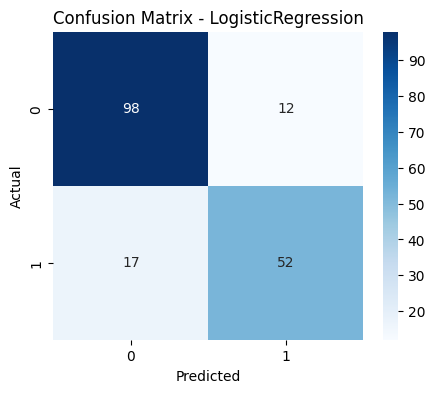

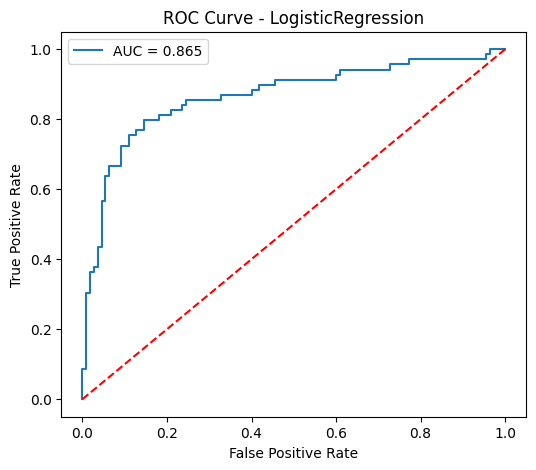

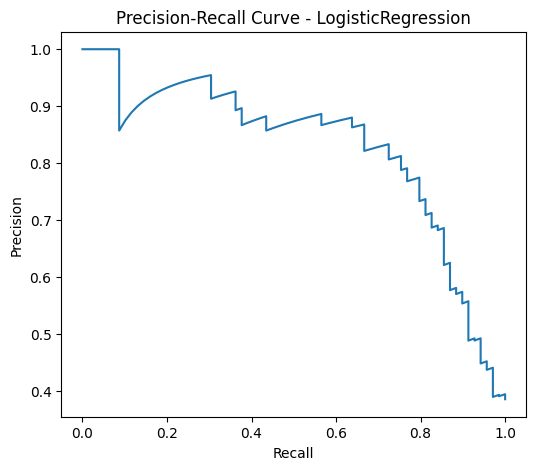


Training RandomForestClassifier ...


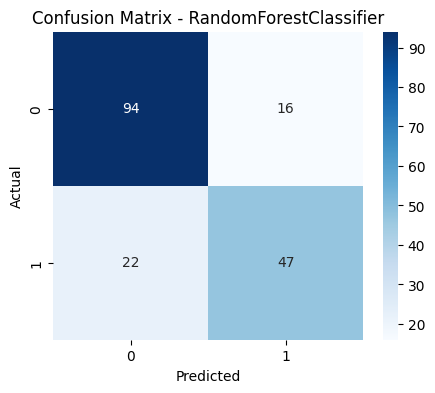

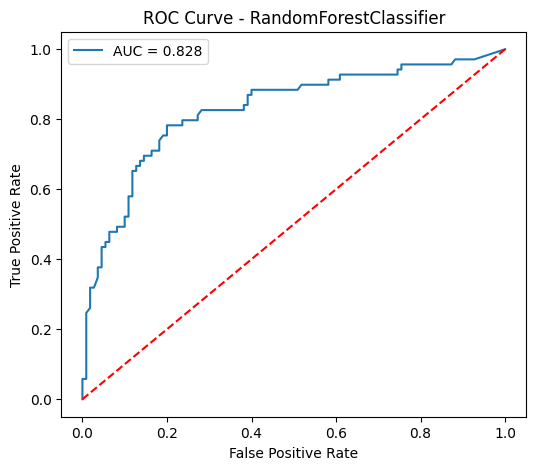

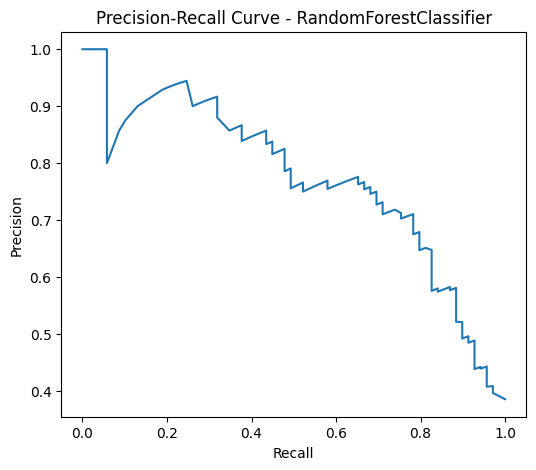


Training XGBClassifier ...


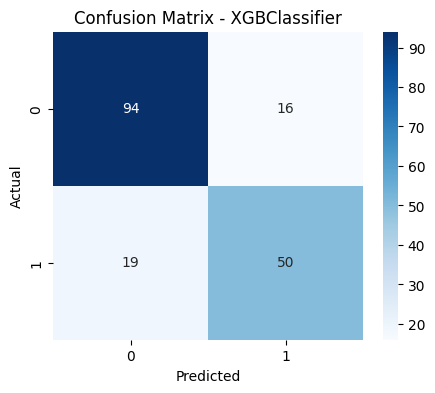

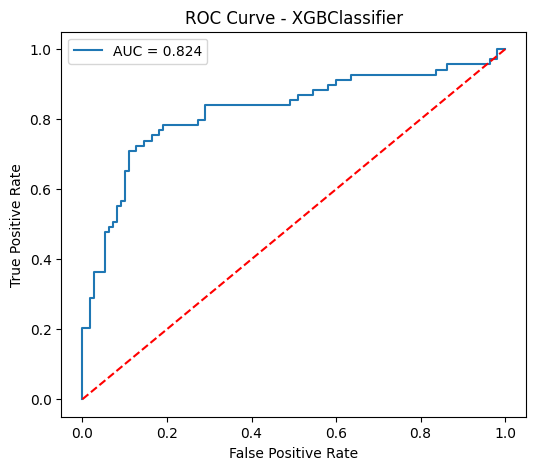

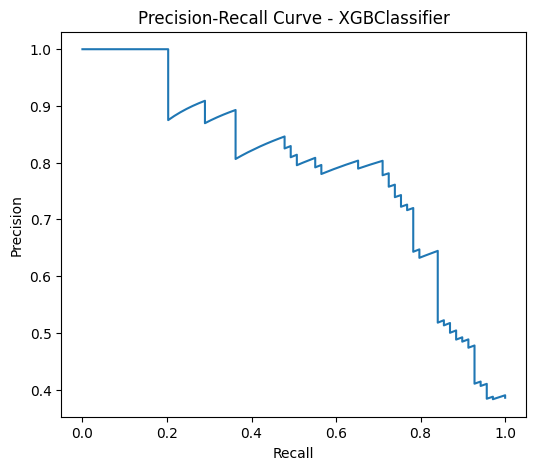


Best model based on AUC: LogisticRegression

submission.csv file created successfully!


,model,Accuracy,Precision,Recall,F1,AUC
0,LogisticRegression,0.837989,0.812500,0.753623,0.781955,0.865349
1,RandomForestClassifier,0.787709,0.746032,0.681159,0.712121,0.827602
2,XGBClassifier,0.804469,0.757576,0.724638,0.740741,0.824111


In [35]:
main(train_processed , test_processed)